In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings

warnings.filterwarnings('ignore')
print("Imports successful ✓")

Imports successful ✓


In [3]:
lgbm_model = joblib.load('../models/lgbm_model.pkl')

X_train = pd.read_csv('../outputs/X_train.csv')
X_val = pd.read_csv('../outputs/X_val.csv')

X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)
X_val.columns = X_val.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)

print("Model and data loaded ✓")
print("X_val shape:", X_val.shape)

Model and data loaded ✓
X_val shape: (61503, 201)


In [4]:
explainer = shap.TreeExplainer(lgbm_model)
print("SHAP explainer created ✓")

SHAP explainer created ✓


In [5]:
sample = X_val.iloc[:500]

shap_values = explainer.shap_values(sample)

print("SHAP values calculated ✓")
print("Shape of shap_values:", shap_values.shape)

SHAP values calculated ✓
Shape of shap_values: (500, 201)


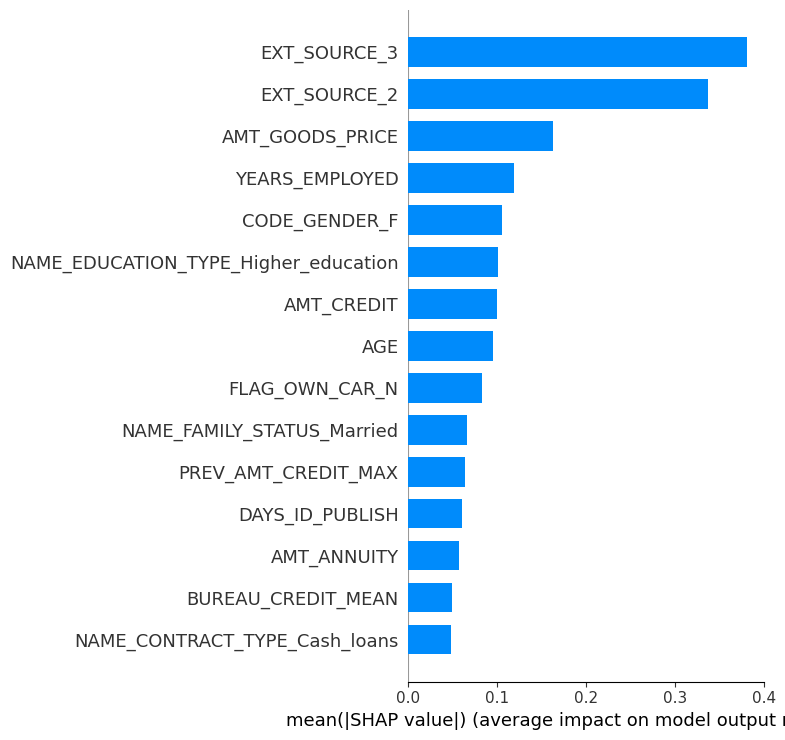

<Figure size 640x480 with 0 Axes>

In [6]:
shap.summary_plot(shap_values, sample, plot_type='bar', max_display=15)
plt.savefig('../outputs/shap_global_importance.png')

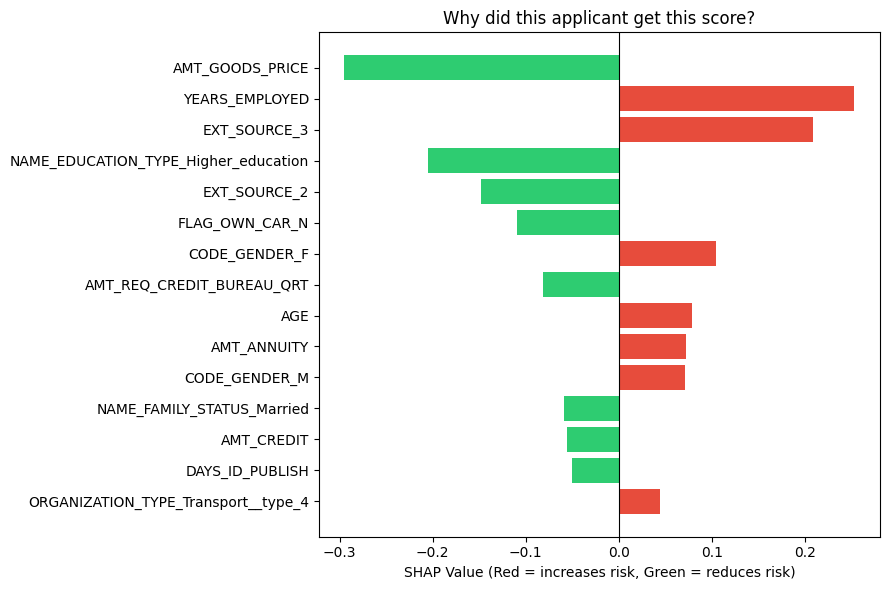

In [15]:
applicant_index = 0
applicant_df = X_val.iloc[[applicant_index]]

single_shap = explainer.shap_values(applicant_df)[0]

shap_df = pd.DataFrame({
    'Feature': X_val.columns.tolist(),
    'SHAP Value': single_shap
})

shap_df = shap_df.reindex(shap_df['SHAP Value'].abs().sort_values(ascending=False).index)
shap_df = shap_df.head(15)

colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in shap_df['SHAP Value']]

plt.figure(figsize=(9, 6))
plt.barh(shap_df['Feature'][::-1], shap_df['SHAP Value'][::-1], color=colors[::-1])
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Why did this applicant get this score?')
plt.xlabel('SHAP Value (Red = increases risk, Green = reduces risk)')
plt.tight_layout()
plt.show()

In [9]:
prob = lgbm_model.predict_proba(X_val.iloc[[applicant_index]])[0][1]

print("Applicant index:", applicant_index)
print("Default probability:", round(prob * 100, 1), "%")

if prob > 0.5:
    print("Verdict: HIGH RISK — likely to default")
else:
    print("Verdict: LOW RISK — likely to repay")

Applicant index: 0
Default probability: 32.7 %
Verdict: LOW RISK — likely to repay


Default probability: 43.1 %


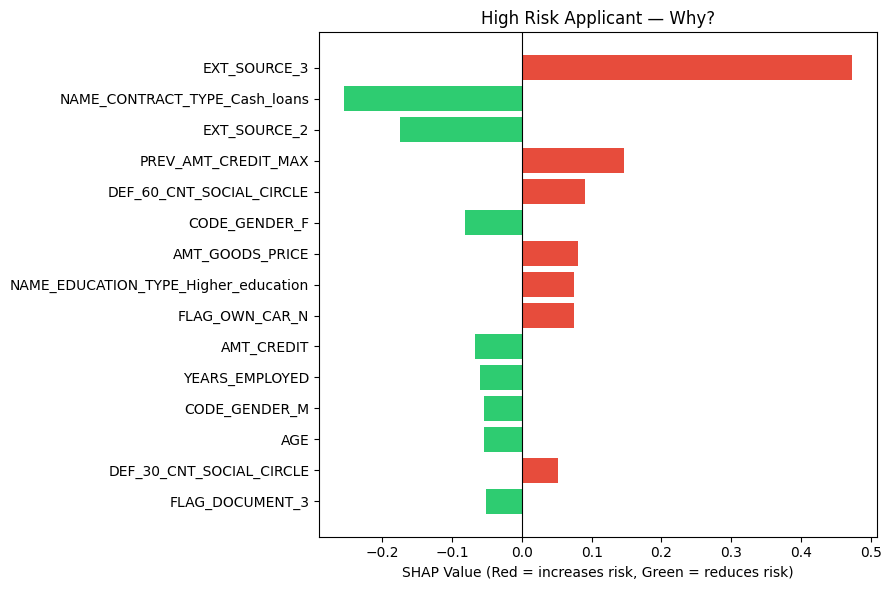

In [17]:
y_val = pd.read_csv('../outputs/y_val.csv').squeeze()

defaulters = y_val[y_val == 1].index.tolist()
high_risk_index = defaulters[0]

high_risk_df = X_val.iloc[[high_risk_index]]
high_risk_shap = explainer.shap_values(high_risk_df)[0]

prob = lgbm_model.predict_proba(high_risk_df)[0][1]
print("Default probability:", round(prob * 100, 1), "%")

shap_df = pd.DataFrame({
    'Feature': X_val.columns.tolist(),
    'SHAP Value': high_risk_shap
})

shap_df = shap_df.reindex(shap_df['SHAP Value'].abs().sort_values(ascending=False).index)
shap_df = shap_df.head(15)

colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in shap_df['SHAP Value']]

plt.figure(figsize=(9, 6))
plt.barh(shap_df['Feature'][::-1], shap_df['SHAP Value'][::-1], color=colors[::-1])
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('High Risk Applicant — Why?')
plt.xlabel('SHAP Value (Red = increases risk, Green = reduces risk)')
plt.tight_layout()
plt.show()